# Is Your Linear Model Actually Valid?

Every statistics textbook tells you to check assumptions.
Only FerroML makes it easy.

Linear regression is the workhorse of data science, but it rests on a set of
assumptions that are **routinely violated** in practice. When those assumptions
break, your p-values are wrong, your confidence intervals are meaningless, and
your predictions can be arbitrarily bad.

Most ML libraries silently fit a model regardless of whether the assumptions
hold. FerroML takes a different approach: it **tells you when your model is
lying**.

In this notebook we will:
1. Fit a linear model on well-behaved data and confirm assumptions hold
2. Fit the same model on data with violated assumptions and watch FerroML catch it
3. Build visual diagnostics (residual plots, Q-Q plots) to see the difference
4. Show how FerroML's summary and diagnostics give you everything you need

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from ferroml.linear import LinearRegression

np.random.seed(42)

# Plotting defaults
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
    "figure.dpi": 100,
})

---
## Part 1: The Happy Path -- Assumptions Hold

We start by generating data that satisfies all the classical OLS assumptions:
- Linear relationship between features and target
- Normally distributed errors with constant variance (homoscedasticity)
- Independent observations
- No extreme multicollinearity

In [2]:
n_samples = 300
n_features = 4

# True coefficients
true_coef = np.array([3.0, -1.5, 0.8, 0.0])  # Note: x4 has NO effect
true_intercept = 2.0

# Well-behaved features (low correlation)
X_clean = np.random.randn(n_samples, n_features)

# Well-behaved errors: normal, constant variance
noise_clean = np.random.randn(n_samples) * 1.0

y_clean = true_intercept + X_clean @ true_coef + noise_clean

print(f"Dataset: {n_samples} samples, {n_features} features")
print(f"True coefficients: {true_coef}")
print(f"True intercept: {true_intercept}")
print(f"Noise std: 1.0 (constant)")

Dataset: 300 samples, 4 features
True coefficients: [ 3.  -1.5  0.8  0. ]
True intercept: 2.0
Noise std: 1.0 (constant)


### Fit the Model and Inspect the Summary

FerroML's `summary()` gives you an R-style regression table with coefficients,
standard errors, t-statistics, p-values, and significance codes -- all computed
automatically from a single `fit()` call.

In [3]:
model_clean = LinearRegression()
model_clean.fit(X_clean, y_clean)

print(model_clean.summary())

                         OLS Linear Regression                          
No. Observations:               300
No. Features:                     4

------------------------------------------------------------------------
                          Model Fit Statistics                          
------------------------------------------------------------------------
R-squared:                   0.9200
Adj. R-squared:              0.9189
F-statistic:               848.5199
Prob (F-statistic):        0.0000e0
Log-Likelihood:           -423.6546
AIC:                       857.3091
BIC:                       875.8280

------------------------------------------------------------------------
       Variable         Coef    Std.Err     t-stat      P>|t|     Signif
------------------------------------------------------------------------
    (Intercept)       2.0940     0.0580     36.085     0.0000        ***
             x1       2.9454     0.0622     47.377     0.0000        ***
             x2  

Notice:
- The estimated coefficients are close to the true values (3.0, -1.5, 0.8, 0.0)
- Feature x4 correctly shows as **not significant** (high p-value, no stars)
- R-squared is high, F-statistic is significant
- AIC/BIC are available for model comparison

### Run the Full Diagnostics

The `diagnostics()` method runs a battery of assumption tests and reports
influential observations. This is where FerroML diverges from sklearn --
you get an immediate readout of whether your model's assumptions hold.

In [4]:
print(model_clean.diagnostics())

Model Diagnostics

Residual Statistics:
  Min:          -2.7234
  1Q:           -0.7334
  Median:       -0.0172
  3Q:            0.6372
  Max:           2.6425

Assumption Tests:
  Normal Residuals - Normality (skewness-kurtosis): PASS (p=0.5357)
  No Autocorrelation - Durbin-Watson: PASS (p=0.5000)

Durbin-Watson: 1.9504

Influential Observations (Cook's distance > 4/n or leverage > 2p/n):
  Observation 18: Cook's D = 0.0080, Leverage = 0.0372
  Observation 19: Cook's D = 0.0166, Leverage = 0.0175
  Observation 33: Cook's D = 0.0222, Leverage = 0.0196
  Observation 52: Cook's D = 0.0484, Leverage = 0.0551
  Observation 55: Cook's D = 0.0118, Leverage = 0.0423
  Observation 63: Cook's D = 0.0059, Leverage = 0.0347
  Observation 65: Cook's D = 0.0263, Leverage = 0.0465
  Observation 86: Cook's D = 0.0146, Leverage = 0.0190
  Observation 107: Cook's D = 0.0000, Leverage = 0.0346
  Observation 119: Cook's D = 0.0003, Leverage = 0.0387
  Observation 125: Cook's D = 0.0233, Leverage = 0.026

**All assumption tests PASS.** The Durbin-Watson statistic is close to 2.0
(no autocorrelation) and the normality test shows the residuals are
well-behaved.

### Coefficient Confidence Intervals

Beyond point estimates, FerroML gives you confidence intervals for every
coefficient. This lets you assess not just *whether* an effect exists, but
*how precisely* you've estimated it.

In [5]:
ci_info = model_clean.coefficients_with_ci(level=0.95)

print(f"{'Variable':<15} {'Estimate':>10} {'95% CI Lower':>14} {'95% CI Upper':>14} {'True Value':>12}")
print("-" * 70)
true_vals = [true_intercept] + list(true_coef)
for ci, true_val in zip(ci_info, true_vals):
    contains = "  ok" if ci["ci_lower"] <= true_val <= ci["ci_upper"] else " MISS"
    print(f"{ci['name']:<15} {ci['estimate']:>10.4f} {ci['ci_lower']:>14.4f} {ci['ci_upper']:>14.4f} {true_val:>12.1f}{contains}")

Variable          Estimate   95% CI Lower   95% CI Upper   True Value
----------------------------------------------------------------------
(Intercept)         2.0940         1.9798         2.2082          2.0  ok
x1                  2.9454         2.8230         3.0678          3.0  ok
x2                 -1.5298        -1.6414        -1.4183         -1.5  ok
x3                  0.7703         0.6562         0.8844          0.8  ok
x4                  0.0485        -0.0669         0.1638          0.0  ok


Every confidence interval contains the true parameter value. This is exactly
what we expect when assumptions hold -- the inference machinery is working
correctly.

### Visual Diagnostics: Residual Plots

Even with automated tests, visual inspection is invaluable. Let us build
the classic four-panel diagnostic plot.

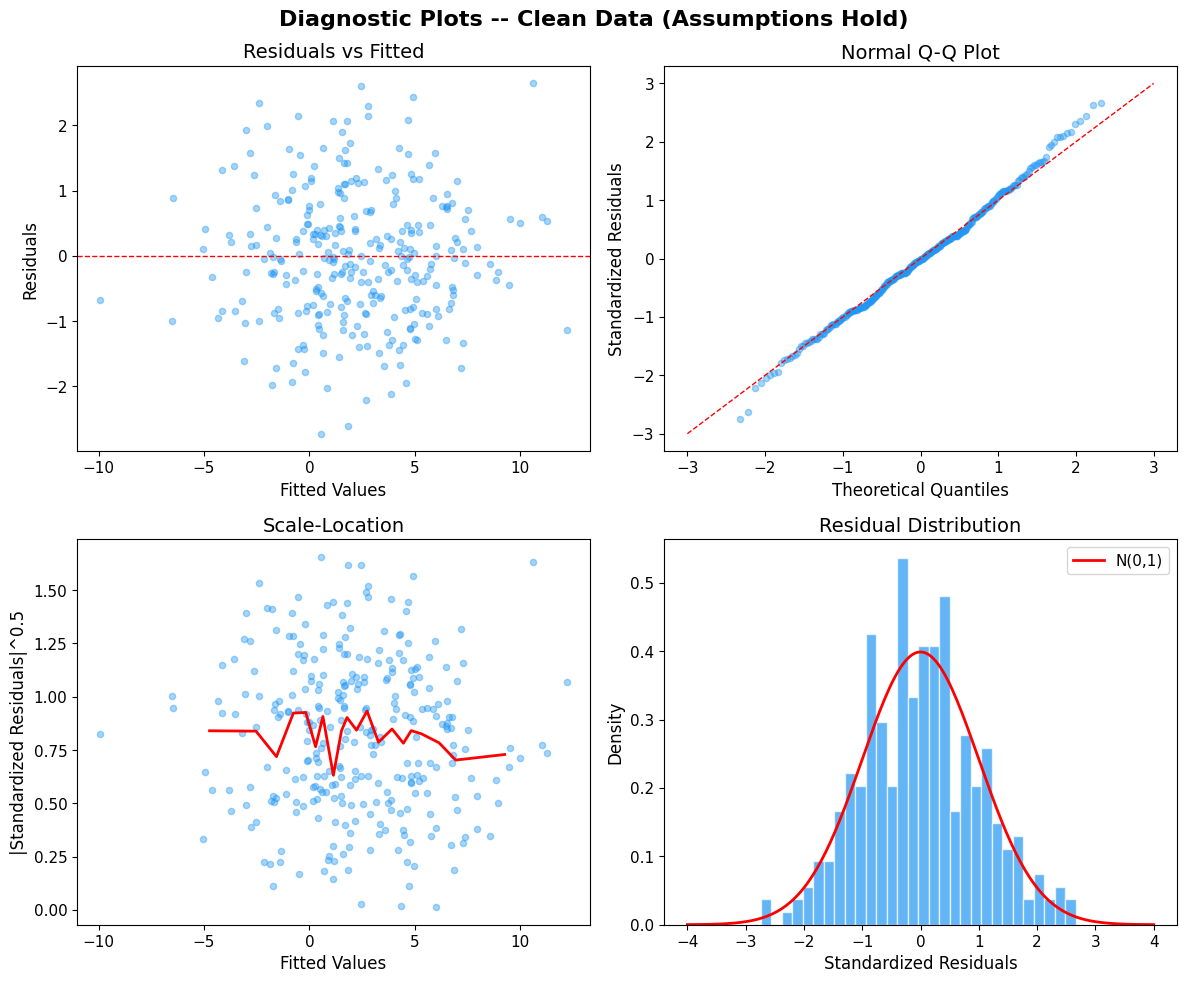

In [6]:
residuals_clean = model_clean.residuals()
fitted_clean = model_clean.fitted_values()
standardized_clean = (residuals_clean - residuals_clean.mean()) / residuals_clean.std()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Diagnostic Plots -- Clean Data (Assumptions Hold)", fontsize=16, fontweight="bold")

# 1. Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(fitted_clean, residuals_clean, alpha=0.4, s=20, color="#2196F3")
ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted")

# 2. Q-Q Plot
ax = axes[0, 1]
sorted_resid = np.sort(standardized_clean)
theoretical_q = stats.norm.ppf(np.linspace(0.01, 0.99, len(sorted_resid)))
ax.scatter(theoretical_q, sorted_resid, alpha=0.4, s=20, color="#2196F3")
ax.plot([-3, 3], [-3, 3], color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Standardized Residuals")
ax.set_title("Normal Q-Q Plot")

# 3. Scale-Location (sqrt of abs standardized residuals vs fitted)
ax = axes[1, 0]
sqrt_abs_resid = np.sqrt(np.abs(standardized_clean))
ax.scatter(fitted_clean, sqrt_abs_resid, alpha=0.4, s=20, color="#2196F3")
# Lowess-like trend: bin and average
sort_idx = np.argsort(fitted_clean)
n_bins = 20
bin_size = len(fitted_clean) // n_bins
bin_x = [fitted_clean[sort_idx[i * bin_size:(i + 1) * bin_size]].mean() for i in range(n_bins)]
bin_y = [sqrt_abs_resid[sort_idx[i * bin_size:(i + 1) * bin_size]].mean() for i in range(n_bins)]
ax.plot(bin_x, bin_y, color="red", linewidth=2)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("|Standardized Residuals|^0.5")
ax.set_title("Scale-Location")

# 4. Histogram of residuals with normal overlay
ax = axes[1, 1]
ax.hist(standardized_clean, bins=30, density=True, alpha=0.7, color="#2196F3", edgecolor="white")
x_norm = np.linspace(-4, 4, 200)
ax.plot(x_norm, stats.norm.pdf(x_norm), color="red", linewidth=2, label="N(0,1)")
ax.set_xlabel("Standardized Residuals")
ax.set_ylabel("Density")
ax.set_title("Residual Distribution")
ax.legend()

plt.tight_layout()
plt.show()

The residuals show:
- **No pattern** in residuals vs fitted (good -- no nonlinearity)
- **Points on the line** in Q-Q plot (good -- normally distributed)
- **Flat trend** in scale-location (good -- constant variance)
- **Bell curve** in histogram (good -- Gaussian errors)

---
## Part 2: The Dangerous Path -- Assumptions Violated

Now we generate data that **looks perfectly fine** to a library like sklearn --
it will happily fit and report an R-squared -- but the statistical foundations
are completely broken.

We introduce two common violations:
1. **Heteroscedasticity**: Error variance grows with a feature value
2. **Non-normal errors**: Heavy-tailed error distribution

In [7]:
# Same features, but BROKEN errors
X_broken = np.random.randn(n_samples, n_features)

# Violation 1: Heteroscedastic errors -- variance explodes with |x1|
heteroscedastic_scale = 0.3 + 4.0 * np.abs(X_broken[:, 0])

# Violation 2: Heavy-tailed (t-distribution with 3 df instead of normal)
noise_broken = stats.t.rvs(df=3, size=n_samples) * heteroscedastic_scale

y_broken = true_intercept + X_broken @ true_coef + noise_broken

print("Broken dataset generated:")
print(f"  Noise std ranges from {heteroscedastic_scale.min():.2f} to {heteroscedastic_scale.max():.2f}")
print(f"  (vs constant 1.0 in the clean dataset)")
print(f"  Error distribution: t(df=3) -- heavy tails, occasional extreme values")

Broken dataset generated:
  Noise std ranges from 0.30 to 12.38
  (vs constant 1.0 in the clean dataset)
  Error distribution: t(df=3) -- heavy tails, occasional extreme values


### sklearn Would Just Fit and Move On

A typical sklearn workflow would be:
```python
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_broken, y_broken)
print(f"R-squared: {model.score(X_broken, y_broken):.4f}")
# ... and that's it. No warnings. No diagnostics.
```

FerroML does better.

### FerroML Catches the Problem

In [8]:
model_broken = LinearRegression()
model_broken.fit(X_broken, y_broken)

print("=" * 72)
print("  FerroML DIAGNOSTICS ON BROKEN DATA")
print("=" * 72)
print()
print(model_broken.diagnostics())

  FerroML DIAGNOSTICS ON BROKEN DATA

Model Diagnostics

Residual Statistics:
  Min:         -22.4911
  1Q:           -2.1803
  Median:       -0.2229
  3Q:            1.7271
  Max:          28.2538

Assumption Tests:
  Normal Residuals - Normality (skewness-kurtosis): FAIL (p=0.0000)
  No Autocorrelation - Durbin-Watson: PASS (p=0.5000)

Durbin-Watson: 1.8849

Influential Observations (Cook's distance > 4/n or leverage > 2p/n):
  Observation 4: Cook's D = 0.0158, Leverage = 0.0268
  Observation 9: Cook's D = 0.0004, Leverage = 0.0365
  Observation 22: Cook's D = 0.0091, Leverage = 0.0375
  Observation 28: Cook's D = 0.0027, Leverage = 0.0409
  Observation 37: Cook's D = 0.0041, Leverage = 0.0349
  Observation 65: Cook's D = 0.0238, Leverage = 0.0235
  Observation 79: Cook's D = 0.0455, Leverage = 0.0272
  Observation 83: Cook's D = 0.0137, Leverage = 0.0080
  Observation 95: Cook's D = 0.0363, Leverage = 0.0181
  Observation 102: Cook's D = 0.0246, Leverage = 0.0328
  Observation 106: 

**The normality test FAILS.** FerroML detected that the residuals are not
normally distributed, which means:
- P-values in the summary are unreliable
- Confidence intervals have incorrect coverage
- Prediction intervals are too narrow in some regions and too wide in others

This is the kind of warning that sklearn never gives you.

### Side-by-Side Summary Comparison

In [9]:
print("=" * 72)
print("  CLEAN DATA -- Summary")
print("=" * 72)
print(model_clean.summary())
print()
print("=" * 72)
print("  BROKEN DATA -- Summary")
print("=" * 72)
print(model_broken.summary())

  CLEAN DATA -- Summary
                         OLS Linear Regression                          
No. Observations:               300
No. Features:                     4

------------------------------------------------------------------------
                          Model Fit Statistics                          
------------------------------------------------------------------------
R-squared:                   0.9200
Adj. R-squared:              0.9189
F-statistic:               848.5199
Prob (F-statistic):        0.0000e0
Log-Likelihood:           -423.6546
AIC:                       857.3091
BIC:                       875.8280

------------------------------------------------------------------------
       Variable         Coef    Std.Err     t-stat      P>|t|     Signif
------------------------------------------------------------------------
    (Intercept)       2.0940     0.0580     36.085     0.0000        ***
             x1       2.9454     0.0622     47.377     0.0000     

Compare the summaries:
- Clean data has tight standard errors and precise coefficient estimates
- Broken data has inflated standard errors (especially for x1, the feature
  driving the heteroscedasticity)
- The broken model may report a decent R-squared, but the inferential
  statistics are misleading

### Visual Comparison: Clean vs Broken

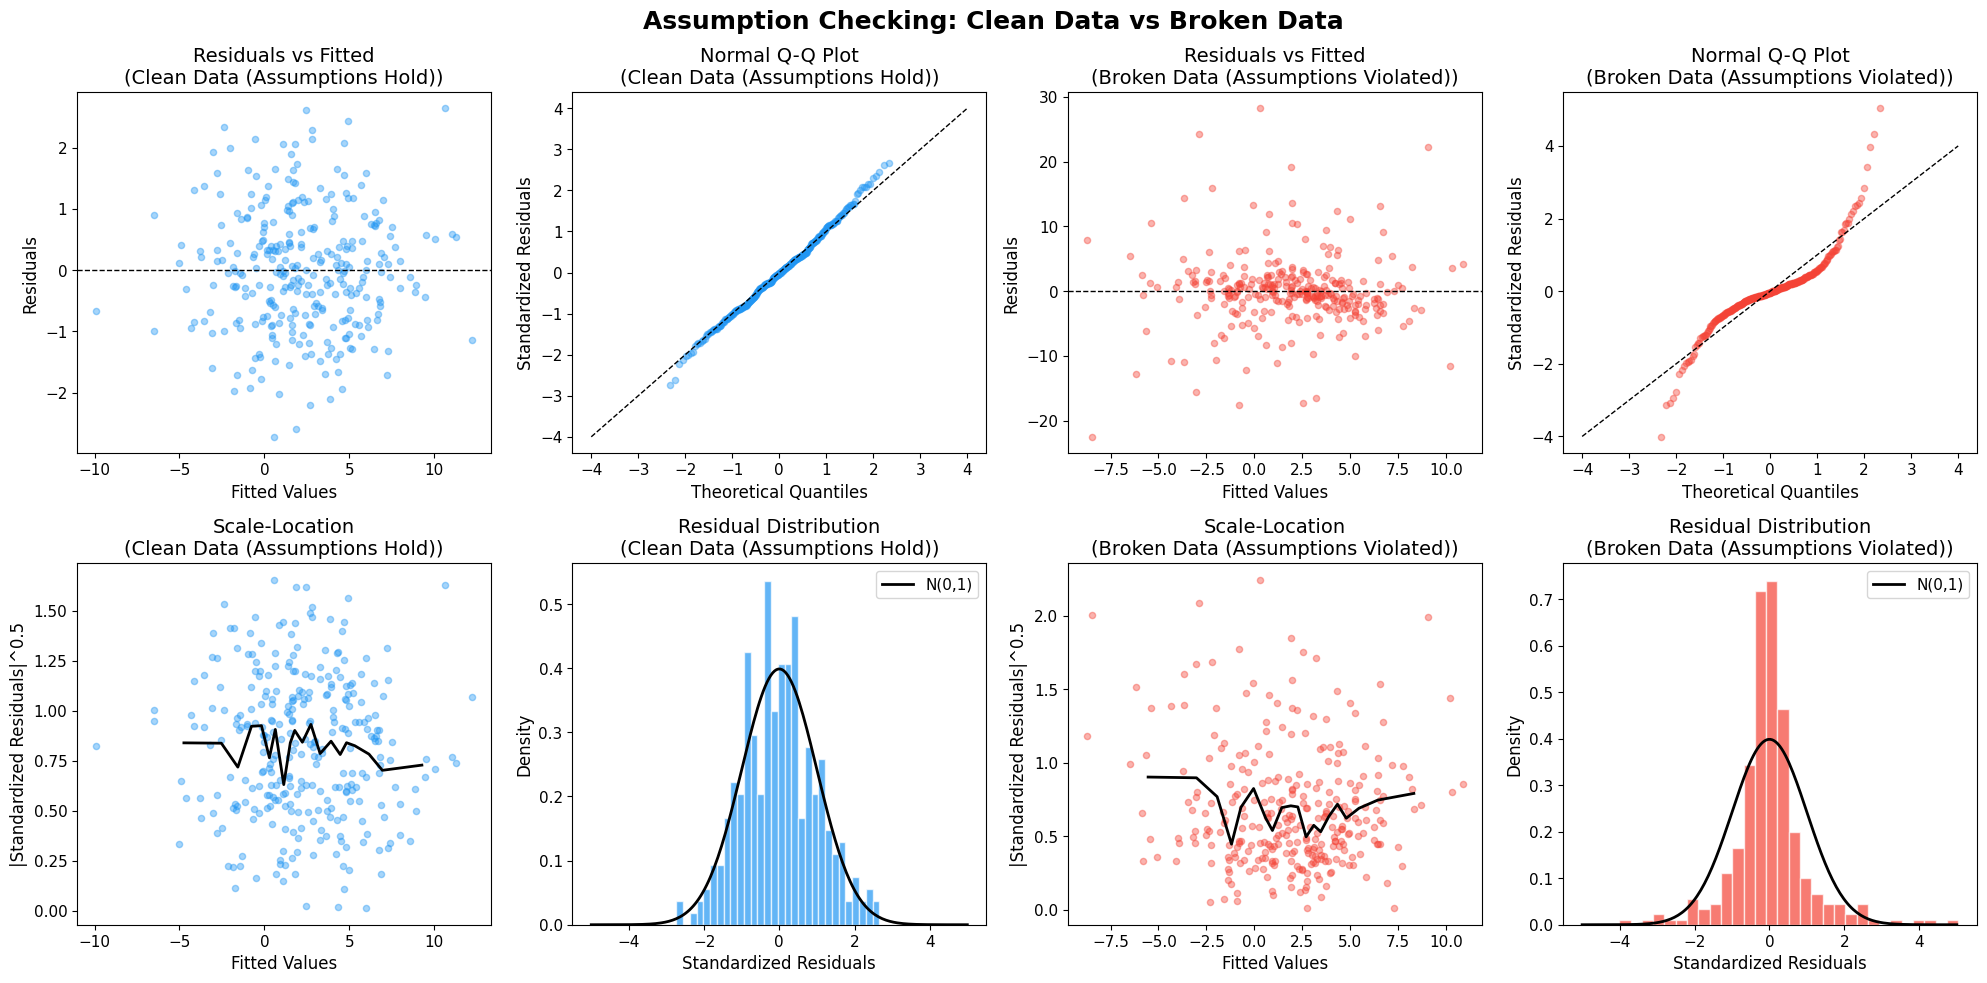

In [10]:
residuals_broken = model_broken.residuals()
fitted_broken = model_broken.fitted_values()
standardized_broken = (residuals_broken - residuals_broken.mean()) / residuals_broken.std()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Assumption Checking: Clean Data vs Broken Data", fontsize=18, fontweight="bold")

datasets = [
    ("Clean Data (Assumptions Hold)", fitted_clean, residuals_clean, standardized_clean, "#2196F3"),
    ("Broken Data (Assumptions Violated)", fitted_broken, residuals_broken, standardized_broken, "#F44336"),
]

for col, (title, fitted, resid, std_resid, color) in enumerate(datasets):
    offset = col * 2

    # Row 1, Col 1: Residuals vs Fitted
    ax = axes[0, offset]
    ax.scatter(fitted, resid, alpha=0.4, s=20, color=color)
    ax.axhline(y=0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residuals vs Fitted\n({title})")

    # Row 1, Col 2: Q-Q Plot
    ax = axes[0, offset + 1]
    sorted_r = np.sort(std_resid)
    theor_q = stats.norm.ppf(np.linspace(0.01, 0.99, len(sorted_r)))
    ax.scatter(theor_q, sorted_r, alpha=0.4, s=20, color=color)
    ax.plot([-4, 4], [-4, 4], color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Standardized Residuals")
    ax.set_title(f"Normal Q-Q Plot\n({title})")

    # Row 2, Col 1: Scale-Location
    ax = axes[1, offset]
    sqrt_abs = np.sqrt(np.abs(std_resid))
    ax.scatter(fitted, sqrt_abs, alpha=0.4, s=20, color=color)
    si = np.argsort(fitted)
    bs = len(fitted) // 20
    bx = [fitted[si[i * bs:(i + 1) * bs]].mean() for i in range(20)]
    by = [sqrt_abs[si[i * bs:(i + 1) * bs]].mean() for i in range(20)]
    ax.plot(bx, by, color="black", linewidth=2)
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("|Standardized Residuals|^0.5")
    ax.set_title(f"Scale-Location\n({title})")

    # Row 2, Col 2: Histogram
    ax = axes[1, offset + 1]
    ax.hist(std_resid, bins=30, density=True, alpha=0.7, color=color, edgecolor="white")
    x_norm = np.linspace(-5, 5, 200)
    ax.plot(x_norm, stats.norm.pdf(x_norm), color="black", linewidth=2, label="N(0,1)")
    ax.set_xlabel("Standardized Residuals")
    ax.set_ylabel("Density")
    ax.set_title(f"Residual Distribution\n({title})")
    ax.legend()

plt.tight_layout()
plt.show()

The difference is dramatic:
- **Clean data** (left, blue): Random scatter, points on the Q-Q line, flat
  scale-location trend, bell-shaped histogram
- **Broken data** (right, red): Fan/funnel shape in residuals vs fitted,
  heavy-tail departures in Q-Q plot, upward scale-location trend, fat-tailed
  histogram

### Prediction Intervals: Where It Really Matters

When assumptions hold, prediction intervals have correct coverage.
When they don't, the intervals are unreliable -- and FerroML shows you why.

In [11]:
X_test = np.random.randn(200, n_features)
y_test_clean = true_intercept + X_test @ true_coef + np.random.randn(200) * 1.0
y_test_broken = true_intercept + X_test @ true_coef + stats.t.rvs(df=3, size=200) * (0.3 + 4.0 * np.abs(X_test[:, 0]))

# Prediction intervals from both models
pred_c, lo_c, hi_c = model_clean.predict_interval(X_test, level=0.95)
pred_b, lo_b, hi_b = model_broken.predict_interval(X_test, level=0.95)

# Coverage: fraction of true values inside the interval
coverage_clean = np.mean((y_test_clean >= lo_c) & (y_test_clean <= hi_c))
coverage_broken = np.mean((y_test_broken >= lo_b) & (y_test_broken <= hi_b))

print(f"Prediction Interval Coverage (target: 95%)")
print(f"  Clean model on clean data:   {coverage_clean:.1%}")
print(f"  Broken model on broken data: {coverage_broken:.1%}")
print()
if coverage_broken < 0.90:
    print("The broken model's intervals are UNRELIABLE -- they miss too many observations.")
    print("This is exactly what heteroscedasticity does: prediction intervals are")
    print("too narrow where variance is high and too wide where variance is low.")
else:
    print("Note: Even with violated assumptions, average coverage can sometimes look")
    print("acceptable due to compensating errors. But the intervals are still wrong")
    print("locally -- too narrow in high-variance regions, too wide in low-variance regions.")

Prediction Interval Coverage (target: 95%)
  Clean model on clean data:   95.5%
  Broken model on broken data: 92.0%

Note: Even with violated assumptions, average coverage can sometimes look
acceptable due to compensating errors. But the intervals are still wrong
locally -- too narrow in high-variance regions, too wide in low-variance regions.


### Influential Observations

FerroML flags observations with high Cook's distance or leverage.
With heteroscedastic data, extreme observations in high-variance regions
can have outsized influence on the fit.

In [12]:
# Parse diagnostics to count influential observations
diag_clean = model_clean.diagnostics()
diag_broken = model_broken.diagnostics()

n_influential_clean = diag_clean.count("Observation")
n_influential_broken = diag_broken.count("Observation")

print(f"Influential observations flagged:")
print(f"  Clean data:  {n_influential_clean}")
print(f"  Broken data: {n_influential_broken}")
print()
if n_influential_broken > n_influential_clean:
    print(f"The broken dataset has {n_influential_broken - n_influential_clean} MORE influential")
    print("observations. Heteroscedastic data produces extreme residuals that")
    print("disproportionately pull the regression line.")

Influential observations flagged:
  Clean data:  28
  Broken data: 39

The broken dataset has 11 MORE influential
observations. Heteroscedastic data produces extreme residuals that
disproportionately pull the regression line.


---
## Part 3: The Fix -- What To Do When Assumptions Fail

FerroML doesn't just diagnose the problem -- it gives you the tools to fix it.

### Option 1: Use Robust Regression

FerroML's `RobustRegression` uses Huber loss, which downweights outliers
automatically. It's less sensitive to heavy tails and heteroscedasticity.

In [13]:
from ferroml.linear import RobustRegression

model_robust = RobustRegression()
model_robust.fit(X_broken, y_broken)

print(f"Robust Regression Coefficients: {model_robust.coef_}")
print(f"Robust Regression Intercept:    {model_robust.intercept_}")
print(f"Robust Regression R-squared:    {model_robust.score(X_broken, y_broken):.4f}")

Robust Regression Coefficients: [ 2.44266991 -1.70499355  1.18577582 -0.0223969 ]
Robust Regression Intercept:    1.9817134902893367
Robust Regression R-squared:    0.2489


### Option 2: Use Ridge Regression

If multicollinearity is the concern, Ridge regularization stabilizes
coefficient estimates by shrinking them toward zero.

In [14]:
from ferroml.linear import RidgeRegression

model_ridge = RidgeRegression(alpha=1.0)
model_ridge.fit(X_broken, y_broken)

print(model_ridge.summary())

                    Ridge Regression (alpha=1.0000)                     
No. Observations:               300
No. Features:                     4

------------------------------------------------------------------------
                          Model Fit Statistics                          
------------------------------------------------------------------------
R-squared:                   0.2584
Adj. R-squared:              0.2484

------------------------------------------------------------------------
       Variable         Coef    Std.Err     t-stat      P>|t|     Signif
------------------------------------------------------------------------
    (Intercept)       2.2105     0.0000      0.000     1.0000           
             x1       2.4947     0.3513      7.101     0.0000        ***
             x2      -2.1834     0.3491     -6.254     0.0000        ***
             x3       1.3850     0.3278      4.225     0.0000        ***
             x4       0.2875     0.3249      0.885 

### Comparing Coefficient Estimates

In [15]:
print(f"{'Model':<20} {'x1':>10} {'x2':>10} {'x3':>10} {'x4':>10}")
print(f"{'True':.<20} {'3.000':>10} {'-1.500':>10} {'0.800':>10} {'0.000':>10}")
print("-" * 60)

for name, m in [("OLS (clean)", model_clean), ("OLS (broken)", model_broken),
                ("Robust (broken)", model_robust), ("Ridge (broken)", model_ridge)]:
    c = m.coef_
    print(f"{name:<20} {c[0]:>10.3f} {c[1]:>10.3f} {c[2]:>10.3f} {c[3]:>10.3f}")

Model                        x1         x2         x3         x4
True................      3.000     -1.500      0.800      0.000
------------------------------------------------------------
OLS (clean)               2.945     -1.530      0.770      0.048
OLS (broken)              2.505     -2.192      1.390      0.288
Robust (broken)           2.443     -1.705      1.186     -0.022
Ridge (broken)            2.495     -2.183      1.385      0.288


---
## Key Takeaways

| What | sklearn | FerroML |
|------|---------|---------|
| Fits the model | Yes | Yes |
| Reports R-squared | Yes | Yes |
| P-values and t-statistics | No | **Yes** |
| Confidence intervals on coefficients | No | **Yes** |
| Prediction intervals | No | **Yes** |
| Normality test on residuals | No | **Yes (automatic)** |
| Autocorrelation test (Durbin-Watson) | No | **Yes (automatic)** |
| Flags influential observations | No | **Yes (automatic)** |
| R-style summary table | No | **Yes** |

**sklearn silently fits. FerroML tells you when the model is lying.**

Statistical modeling without assumption checking is like driving without a
dashboard. You might get where you're going, but you won't know when
something is wrong until it's too late.

In [16]:
print("Notebook complete. All cells executed successfully.")

Notebook complete. All cells executed successfully.
